# Kiểm tra và phân tích dữ liệu văn bản hành chính

Notebook này được sử dụng để kiểm tra và phân tích hai nguồn dữ liệu chính của dự án:

1. **Bộ mẫu văn bản hành chính (forms)** được lưu dưới dạng Markdown.
2. **Bộ dữ liệu văn bản pháp luật / hành chính** được lưu dưới dạng Parquet.

Mục tiêu của notebook là giúp nhóm dự án:

- Hiểu cấu trúc dữ liệu
- Kiểm tra tính đầy đủ và tính nhất quán của dữ liệu
- Xác minh schema trước khi đưa dữ liệu vào các bước xử lý tiếp theo

Kết quả của quá trình phân tích này sẽ giúp đảm bảo dữ liệu sẵn sàng cho các bước như:

- Xây dựng hệ thống RAG (Retrieval Augmented Generation)
- Trích xuất thông tin từ văn bản
- Sinh văn bản hành chính từ template

## Tổng quan về các bộ dữ liệu

Dự án sử dụng hai loại dữ liệu khác nhau:

### 1. Bộ mẫu văn bản hành chính (Markdown Forms)

Đây là các **mẫu văn bản hành chính chuẩn**, được chuyển sang định dạng Markdown.

Các mẫu văn bản bao gồm:

- Nghị quyết
- Quyết định
- Công văn
- Công điện
- Giấy mời
- Biên bản
- Giấy giới thiệu
- Giấy nghỉ phép

Mỗi file Markdown gồm:

- Phần **metadata (YAML frontmatter)** mô tả loại văn bản
- Nội dung **template văn bản**
- Các **placeholder** dùng để điền thông tin thực tế

Ví dụ placeholder:


## Quy trình thực hiện trong notebook

Notebook được tổ chức theo các bước sau:

1. Đọc các file Markdown của template văn bản
2. Trích xuất metadata từ YAML frontmatter
3. Phân tích cấu trúc template
4. Đọc dataset Parquet
5. Kiểm tra schema của dataset
6. Phân tích dữ liệu mẫu
7. Thống kê cơ bản

Các bước này giúp nhóm dự án hiểu rõ cấu trúc dữ liệu trước khi tiến hành các bước xử lý tiếp theo.

## Hướng dẫn chạy notebook

Để chạy notebook này cần cài đặt các thư viện Python sau:

- pandas
- pyarrow
- pathlib
- pyyaml

Sau đó:

1. Cập nhật đường dẫn tới dataset nếu cần.
2. Chạy các cell theo thứ tự từ trên xuống.
3. Kiểm tra kết quả hiển thị ở từng bước.

Notebook được thiết kế để các thành viên trong nhóm có thể dễ dàng kiểm tra dữ liệu trước khi sử dụng trong pipeline của dự án.

## Lưu ý

- Các file Markdown chỉ là **mẫu văn bản (templates)**, không phải văn bản thực tế.
- Dataset Parquet chứa **văn bản hành chính và pháp luật thực tế**.
- Các placeholder trong template sẽ được sử dụng cho:

  - Sinh văn bản tự động
  - Trích xuất thông tin
  - So khớp với văn bản thực

Nếu phát hiện lỗi về schema hoặc dữ liệu thiếu, cần báo lại để chỉnh sửa dataset trước khi đưa vào các bước xử lý tiếp theo.

In [30]:
import pandas as pd
import numpy as np

legal_path = "dataset/legal_dataset.parquet"
form_path = "Forms/md"

# Kiểm tra các forms văn bản có sẵn (10 forms)

In [31]:
forms_df = pd.read_parquet("dataset/forms_dataset.parquet", engine="fastparquet")
print(f"Tổng số biểu mẫu: {len(forms_df)}")
print(f"\nDanh sách biểu mẫu:")
print(forms_df[['form_id', 'form_type', 'purpose']].to_markdown(index=False))

# Thống kê số lượng trường bắt buộc (required_fields) cho mỗi biểu mẫu
forms_df['num_required_fields'] = forms_df['required_fields'].apply(len)
print(f"\nSố trường bắt buộc trung bình mỗi form: {forms_df['num_required_fields'].mean():.1f}")
print(forms_df[['form_id', 'form_type', 'num_required_fields']].to_markdown(index=False))


Tổng số biểu mẫu: 10

Danh sách biểu mẫu:
| form_id   | form_type                                                                                                                                                                          | purpose                                  |
|:----------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------|
| Form_07   | Giấy mời                                                                                                                                                                           | Mời họp, hội nghị, hội thảo              |
| Form_05   | Công văn                                                                                                                                                                           | Giao dịch, trao đổi công việc hành chính |
| Form

# Kiểm tra dataset văn bản pháp luật

### 2. Bộ dữ liệu văn bản pháp luật / hành chính (Parquet)

Bộ dữ liệu thứ hai chứa **các văn bản hành chính và pháp luật thực tế**.

Dữ liệu được lưu ở định dạng **Parquet** nhằm:

- Tối ưu dung lượng lưu trữ
- Tăng tốc độ đọc dữ liệu
- Phù hợp cho xử lý dữ liệu lớn

Dataset bao gồm các trường như:

- id
- ministry
- type
- date
- name
- chapter_id
- chapter_name
- article
- content

Trong notebook này chúng ta sẽ:

- Kiểm tra schema của dataset
- Xem một số bản ghi mẫu
- Kiểm tra giá trị thiếu (missing values)
- Phân tích sơ bộ dữ liệu

In [41]:
legal_df = pd.read_parquet(legal_path, engine = "fastparquet")
print(legal_df.columns)

Index(['id', 'ministry', 'type', 'name', 'chapter_id', 'chapter_name',
       'article', 'content'],
      dtype='str')


In [42]:
unique_legal_df = legal_df['type'].value_counts().reset_index()
unique_legal_df.columns = ['Loại văn bản', 'Số lượng']
print(unique_legal_df.to_markdown(index=False))

| Loại văn bản                                                                   |   Số lượng |
|:-------------------------------------------------------------------------------|-----------:|
| THÔNG TƯ                                                                       |     147670 |
| QUYẾT ĐỊNH                                                                     |     130574 |
| NGHỊ QUYẾT                                                                     |      90768 |
| NGHỊ ĐỊNH                                                                      |      82882 |
| LUẬT                                                                           |      32609 |
| QUYẾT                                                                          |       8041 |
| ĐỊNH                                                                           |            |
| none                                                                           |       6660 |
| NGHỊ                                  

In [43]:
#Print first row of legal_df
print(legal_df.iloc[0])

id                                     01/2014/NQLT/CP-UBTƯMTTQVN
ministry        CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC...
type                                         NGHỊ QUYẾT LIÊN TỊCH
name            HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH C...
chapter_id                                               Chương I
chapter_name                                 NHỮNG QUY ĐỊNH CHUNG
article                                Điều 1. Phạm vi điều chỉnh
content         Nghị quyết liên tịch này hướng dẫn phối hợp th...
Name: 0, dtype: object


In [44]:
# Danh sách các văn bản "sống còn" cho soạn thảo hành chính và RAG
# Key: Tên hiển thị, Value: Regex để tìm kiếm
important_laws = {
    "Nghị định 30/2020/NĐ-CP (Văn thư)": r"30/2020/NĐ-CP",
    "Bộ luật Lao động 2019": r"45/2019/QH14|Lao động 2019",
    "Luật Cán bộ, công chức": r"Luật Cán bộ, công chức",
    "Luật Viên chức": r"Luật Viên chức",
    "Luật Ban hành văn bản QPPL": r"80/2015/QH13|15/2020/QH14",
    "Luật Lưu trữ": r"01/2011/QH13",
    "Luật Tổ chức Chính phủ": r"Luật Tổ chức Chính phủ",
    "Luật Tổ chức chính quyền địa phương": r"Luật Tổ chức chính quyền địa phương"
}

def check_legal_coverage(legal_df):
    print(f"--- Đang bắt đầu phân tích: ---")
    
    # 1. Chỉ đọc các cột cần thiết để tối ưu bộ nhớ
    cols = ['id', 'name', 'type', 'ministry']
    try:
        # Đọc dữ liệu (Chỉ lấy metadata để kiểm tra cho nhanh)
        df = legal_df
        print(f"✅ Đã tải thành công {len(df):,} bản ghi.\n")
    except Exception as e:
        print(f"❌ Lỗi khi đọc file: {e}")
        return

    # 2. Kiểm tra danh mục văn bản quan trọng
    results = []
    print("Đang quét các văn bản cốt lõi...")
    
    for label, pattern in important_laws.items():
        # Kiểm tra đồng thời trong cột 'id' và 'name'
        found_mask = (
            df['id'].str.contains(pattern, case=False, na=False) | 
            df['name'].str.contains(pattern, case=False, na=False)
        )
        count = found_mask.sum()
        status = "✅ CÓ" if count > 0 else "❌ THIẾU"
        results.append({
            "Văn bản pháp lý": label,
            "Trạng thái": status,
            "Số lượng dòng (Articles)": count
        })

    # In báo cáo dưới dạng bảng
    report_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("BÁO CÁO ĐỘ PHỦ DỮ LIỆU PHÁP LUẬT")
    print("="*60)
    print(report_df.to_string(index=False))
    print("="*60)

    # 3. Thống kê chuyên sâu về cơ cấu dữ liệu
    print("\nTOP 5 CƠ QUAN BAN HÀNH NHIỀU NHẤT:")
    print(df['ministry'].value_counts().head(5))

    print("\nTOP 5 LOẠI VĂN BẢN PHỔ BIẾN:")
    print(df['type'].value_counts().head(5))

if __name__ == "__main__":
    check_legal_coverage(legal_df)

--- Đang bắt đầu phân tích: ---
✅ Đã tải thành công 515,188 bản ghi.

Đang quét các văn bản cốt lõi...

BÁO CÁO ĐỘ PHỦ DỮ LIỆU PHÁP LUẬT
                    Văn bản pháp lý Trạng thái  Số lượng dòng (Articles)
  Nghị định 30/2020/NĐ-CP (Văn thư)       ✅ CÓ                        63
              Bộ luật Lao động 2019       ✅ CÓ                       220
             Luật Cán bộ, công chức       ✅ CÓ                       164
                     Luật Viên chức       ✅ CÓ                        48
         Luật Ban hành văn bản QPPL       ✅ CÓ                       180
                       Luật Lưu trữ       ✅ CÓ                        42
             Luật Tổ chức Chính phủ       ✅ CÓ                         4
Luật Tổ chức chính quyền địa phương       ✅ CÓ                         4

TOP 5 CƠ QUAN BAN HÀNH NHIỀU NHẤT:
ministry
CHÍNH PHỦ                85021
QUỐC HỘI                 32538
BỘ TÀI CHÍNH             27455
BỘ GIAO THÔNG VẬN TẢI    14169
BỘ CÔNG THƯƠNG           11106
Name: 

## 3. Phân tích Dữ liệu Chuyên sâu cho RAG (Retrieval-Augmented Generation)

Để đảm bảo bộ dữ liệu Parquet này sẵn sàng cho việc xây dựng Vector Database, chúng ta cần kiểm tra 3 yếu tố quan trọng:
1. **Chất lượng dữ liệu (Data Quality):** Kiểm tra giá trị thiếu (Missing values) và dữ liệu rác.
2. **Độ trùng lặp (Duplication):** Đánh giá mức độ trùng lặp nội dung để tối ưu hóa không gian lưu trữ và tránh ảnh hưởng tới kết quả truy xuất.
3. **Phân bổ Độ dài (Text Length Distribution):** Đánh giá xem dữ liệu đã được chia mảnh (chunking) phù hợp với Context Window của mô hình LLM chưa.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### 3.1. Kiểm tra Chất lượng Dữ liệu (Missing Values)
Dữ liệu rỗng ở cột `content` sẽ khiến quá trình tạo Embedding bị lỗi. Ta phải loại bỏ chúng trước khi nạp vào Vector DB.


In [37]:
def check_missing_values(df):
    print("--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---")
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_report = pd.DataFrame({
        'Số lượng thiếu': missing_data,
        'Tỷ lệ (%)': missing_percent.round(2)
    })
    
    print(missing_report[missing_report['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ (%)', ascending=False))
    print(f"\nTổng số bản ghi: {len(df):,}")
    
    # Nếu cột content (quan trọng nhất cho RAG) bị null
    if 'content' in df.columns:
        empty_content = df[df['content'].str.strip() == ''].shape[0]
        print(f"Số dòng có content rỗng (nhưng không phải NaN): {empty_content:,} ({empty_content/len(df)*100:.2f}%)")

# Chạy kiểm tra
check_missing_values(legal_df)


--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---
            Số lượng thiếu  Tỷ lệ (%)
content              90706      17.61
ministry               757       0.15
id                     350       0.07
article                309       0.06
type                    35       0.01
name                    16       0.00
chapter_id               3       0.00

Tổng số bản ghi: 515,188
Số dòng có content rỗng (nhưng không phải NaN): 0 (0.00%)


### 3.2. Kiểm tra Độ trùng lặp (Duplication)
Việc trùng lặp các bài báo/số liệu luật sẽ làm mô hình Vector DB phình to (tăng phí lưu trữ, làm nhiễu kết quả Context Retrieval).


In [38]:
def check_duplicates(df):
    print("--- KIỂM TRA ĐỘ TRÙNG LẶP NỘI DUNG ---")
    
    # Kiểm tra trùng lặp toàn bộ dòng
    exact_duplicates = df.duplicated().sum()
    print(f"Số dòng trùng lặp y hệt: {exact_duplicates:,} ({exact_duplicates/len(df)*100:.2f}%)")
    
    # Kiểm tra trùng lặp nội dung (content)
    if 'content' in df.columns:
        content_duplicates = df.duplicated(subset=['content']).sum()
        print(f"Số dòng có cùng văn bản content: {content_duplicates:,} ({content_duplicates/len(df)*100:.2f}%)")

check_duplicates(legal_df)


--- KIỂM TRA ĐỘ TRÙNG LẶP NỘI DUNG ---
Số dòng trùng lặp y hệt: 2,433 (0.47%)
Số dòng có cùng văn bản content: 123,108 (23.90%)


### 3.3. Phân bổ Độ dài văn bản (Text Length / Token Distribution)
**Lý do:** Các mô hình embedding (như text-embedding-3-small) thường bị giới hạn tokens (ví dụ: tối đa 8192 token). Dựa vào biểu đồ này, ta sẽ biết nên cắt nhỏ file gốc ra bao nhiêu `chunk_size` khi sử dụng LangChain.


--- PHÂN TÍCH ĐỘ DÀI VĂN BẢN TỪ CỘT: 'content' ---

Thống kê mô tả (Số từ/dòng):
count    10000.00
mean       269.97
std        528.41
min          0.00
25%         40.00
50%        128.00
75%        288.25
max       9127.00
Name: word_count, dtype: float64


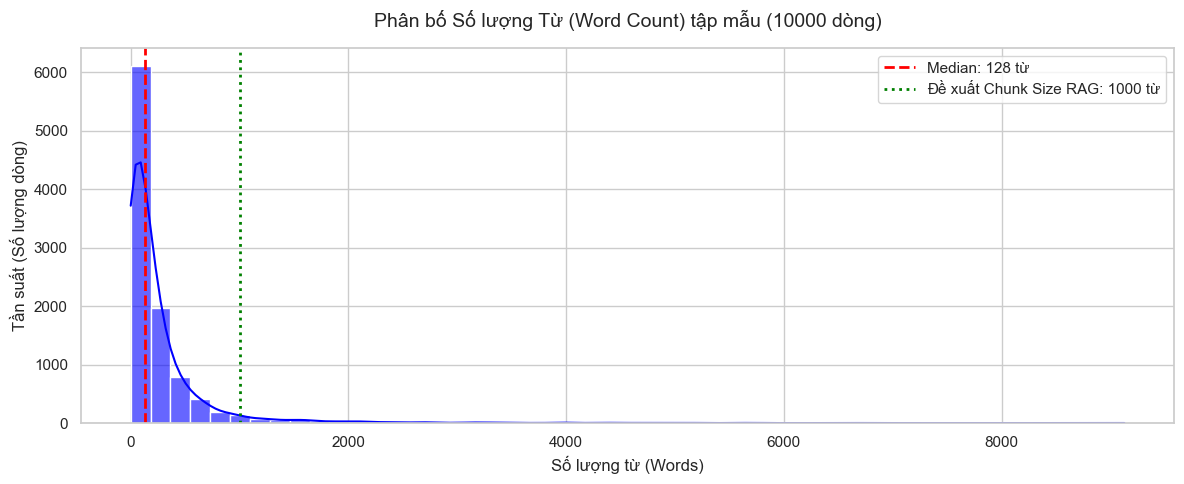

In [39]:
def plot_text_length_distribution(df, column_name='content', sample_size=10000):
    print(f"--- PHÂN TÍCH ĐỘ DÀI VĂN BẢN TỪ CỘT: '{column_name}' ---")
    
    if column_name not in df.columns:
        print(f"Không tìm thấy cột {column_name}")
        return
        
    # Để tiết kiệm RAM khi vẽ biểu đồ, lấy ngẫu nhiên một mẫu dữ liệu (sample)
    df_sample = df.sample(min(sample_size, len(df))) if len(df) > sample_size else df
    
    # Tính độ dài theo số từ (words) - giả lập Token
    df_sample['word_count'] = df_sample[column_name].fillna('').astype(str).apply(lambda x: len(x.split()))

    print("\nThống kê mô tả (Số từ/dòng):")
    print(df_sample['word_count'].describe().round(2))
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 5))
    sns.histplot(df_sample['word_count'], bins=50, kde=True, color='blue', alpha=0.6)
    
    plt.title(f"Phân bố Số lượng Từ (Word Count) tập mẫu ({min(sample_size, len(df))} dòng)", fontsize=14, pad=15)
    plt.xlabel("Số lượng từ (Words)", fontsize=12)
    plt.ylabel("Tần suất (Số lượng dòng)", fontsize=12)
    plt.axvline(df_sample['word_count'].median(), color='red', linestyle='dashed', linewidth=2, label=f"Median: {df_sample['word_count'].median():.0f} từ")
    plt.axvline(1000, color='green', linestyle='dotted', linewidth=2, label="Đề xuất Chunk Size RAG: 1000 từ")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# Chạy vẽ đồ thị
plot_text_length_distribution(legal_df)


### 3.4. Mô phỏng thử truy xuất Semantic Search (Mock RAG Retrieval Test)
Giả lập việc User đặt một câu prompt tìm kiếm, kiểm tra xem DataSet luật có phản ứng ra đúng kết quả không.


In [40]:
def mock_retrieval(df, keyword, num_results=3):
    print(f"\n--- TÌM KIẾM TỪ KHÓA: '{keyword}' ---")
    
    if 'content' not in df.columns:
        return
        
    # Tìm các dòng chứa keyword (không phân biệt hoa thường)
    results = df[df['content'].str.contains(keyword, case=False, na=False)]
    
    print(f"Tìm thấy {len(results):,} kết quả có chứa từ khóa.\n")
    
    if len(results) > 0:
        for idx, (_, row) in enumerate(results.head(num_results).iterrows()):
            content = str(row['content'])
            key_idx = content.lower().find(keyword.lower())
            
            # Trích xuất 1 đoạn ngắn bao quanh keyword
            start_idx = max(0, key_idx - 50)
            end_idx = min(len(content), key_idx + len(keyword) + 150)
            
            snippet = content[start_idx:end_idx].replace('\n', ' ')
            if start_idx > 0: snippet = "..." + snippet
            if end_idx < len(content): snippet += "..."
            
            print(f"Kết quả {idx+1}:")
            print(f"📌 Nguồn: {row.get('name', 'N/A')} | {row.get('type', 'N/A')} ({row.get('ministry', 'N/A')})")
            print(f"📄 Đoạn trích: {snippet}\n")

# Thử nghiệm truy xuất với 2 từ khóa hành chính phổ biến
mock_retrieval(legal_df, "nghỉ thai sản")
mock_retrieval(legal_df, "kỷ luật công chức")



--- TÌM KIẾM TỪ KHÓA: 'nghỉ thai sản' ---
Tìm thấy 123 kết quả có chứa từ khóa.

Kết quả 1:
📌 Nguồn: LAO ĐỘNG | LUẬT (QUỐC HỘI)
📄 Đoạn trích: ... Người lao động nữ mang thai; người lao động đang nghỉ thai sản hoặc nuôi con dưới 12 tháng tuổi.

Kết quả 2:
📌 Nguồn: LAO ĐỘNG | LUẬT (QUỐC HỘI)
📄 Đoạn trích: ... định; b) Thay thế người lao động trong thời gian nghỉ thai sản, bị tai nạn lao động, bệnh nghề nghiệp hoặc phải thực hiện các nghĩa vụ công dân; c) Có nhu cầu sử dụng lao động trình độ chuyên môn, kỹ thuật cao. 3...

Kết quả 3:
📌 Nguồn: LAO ĐỘNG | LUẬT (QUỐC HỘI)
📄 Đoạn trích: ...y; d) Người lao động nữ mang thai; người lao động nghỉ thai sản, nuôi con dưới 12 tháng tuổi. 5. Không xử lý kỷ luật lao động đối với người lao động vi phạm kỷ luật lao động trong khi mắc bệnh tâm thần hoặc một bệ...


--- TÌM KIẾM TỪ KHÓA: 'kỷ luật công chức' ---
Tìm thấy 107 kết quả có chứa từ khóa.

Kết quả 1:
📌 Nguồn: TỔ CHỨC QUỐC HỘI | LUẬT (QUỐC HỘI)
📄 Đoạn trích: ...hội trong việc tuyển dụng, bổ nhi